# 03 — Custom CNN
In the previous stage, we established a performance floor using a shallow CNN. However, artistic styles in the WikiArt dataset are defined by complex textures, color gradients, and brushstroke patterns that require a deeper hierarchy of features.

In this notebook, we implement a Custom CNN designed specifically for this task, incorporating:
1. **Depth**: More convolutional layers to capture high-level artistic features.
2. **Batch Normalization**: To stabilize and accelerate the training process.
3. **Global Average Pooling**: To reduce the number of parameters and combat overfitting.
4. **Advanced Dropout**: To ensure the model generalizes well to unseen paintings.

This notebook covers:
1. **Dataset Integration**: Loading the pre-processed WikiArt subset using the build_datasets pipeline.
2. **Hyperparameter Tuning**: Using RandomSearch in order to explore the hyperparameter space.
3. **Advanced Training**: Implementing Model Checkpoints and Early Stopping to capture the best performing weights.
4. **Performance Analysis**: Saving the optimized model and training logs for cross-model evaluation.

In [9]:
import sys
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import keras_tuner as kt

sys.path.insert(0, os.path.abspath(".."))

from src.data_loader import build_datasets
from src.models.custom_cnn import build_custom_model, custom_model_builder

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50 # Increased epochs as the model is deeper

## 1. Loading the Pre-processed WikiArt Dataset

In [10]:
train_ds, val_ds, test_ds, NUM_CLASSES = build_datasets(
    splits_dir="../data/splits",
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    use_processed=True,
    processed_dir="../data/processed"
)

print(f"Data pipeline ready for {NUM_CLASSES} classes.")

Data pipeline ready for 23 classes.


## 2. Hyperparameter Tuning 
To optimize the Custom CNN, we use **Random Search**. This allows us to efficiently explore 
the hyperparameter space (Learning Rate, Dropout, and Filters) to find the best configuration 
for the WikiArt dataset without the exhaustive cost of a Grid Search.

In [11]:
# One-hot encode labels for F1Score metric compatibility
train_ds_oh = train_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))
val_ds_oh = val_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))

"""
# --- Random Search (already executed, best results hardcoded below) ---
tuner = kt.RandomSearch(
    lambda hp: custom_model_builder(hp, num_classes=NUM_CLASSES),
    objective=kt.Objective('val_f1_macro', direction='max'),
    max_trials=50,
    directory='../results/tuning',    
    project_name='wikiart_custom',
    overwrite=True,
    logger=None           
)

tuner.search(train_ds_oh, epochs=10, validation_data=val_ds_oh)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best LR: {best_hps.get('learning_rate')}")
print(f"Best Dropout: {best_hps.get('dropout_rate')}")
print(f"Best Initial Filters: {best_hps.get('num_filters')}")
"""

# Best hyperparameters found via Random Search (50 trials, 10 epochs each)
best_hps = {
    'learning_rate': 0.0004247879117781972,
    'dropout_rate': 0.3,
    'num_filters': 32
}

print("Best hyperparameters from tuning:")
for k, v in best_hps.items():
    print(f"  - {k}: {v}")

Best hyperparameters from tuning:
  - learning_rate: 0.0004247879117781972
  - dropout_rate: 0.3
  - num_filters: 32


## 3. Advanced Training
For this model, we are using a more robust training strategy:
* **Early Stopping**: Set to 5 epochs of patience to avoid wasting computational resources if the model stagnates.
* **Model Checkpoints**: Automatically saving the best version of the model based on `val_loss`.

In [12]:
os.makedirs('../results/logs', exist_ok=True)
os.makedirs('../results/models', exist_ok=True)

model = build_custom_model(
    num_classes=NUM_CLASSES,
    learning_rate=best_hps['learning_rate'],
    dropout_rate=best_hps['dropout_rate'],
    num_filters=best_hps['num_filters']
)

model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('../results/logs/custom_cnn.csv'),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='../results/models/custom_cnn.keras',
        monitor='val_loss',
        save_best_only=True
    )
]

history = model.fit(
    train_ds_oh,
    validation_data=val_ds_oh,
    epochs=EPOCHS,
    callbacks=callbacks
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,039 (1.76 MB)

 Trainable params: 461,079 (1.76 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 117s 396ms/step - accuracy: 0.2373 - f1_macro: 0.1800 - loss: 2.6274 - val_accuracy: 0.0360 - val_f1_macro: 0.0113 - val_loss: 4.9892
Epoch 2/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 114s 390ms/step - accuracy: 0.3119 - f1_macro: 0.2569 - loss: 2.3144 - val_accuracy: 0.2904 - val_f1_macro: 0.1966 - val_loss: 2.4827
Epoch 3/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 117s 400ms/step - accuracy: 0.3596 - f1_macro: 0.3021 - loss: 2.1342 - val_accuracy: 0.3623 - val_f1_macro: 0.2999 - val_loss: 2.0613
Epoch 4/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 126s 431ms/step - accuracy: 0.3905 - f1_macro: 0.3327 - loss: 2.0136 - val_accuracy: 0.3733 - val_f1_macro: 0.3012 - val_loss: 2.0510
Epoch 5/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 144s 494ms/step - accuracy: 0.4263 - f1_macro: 0.3754 - loss: 1.8927 - val_accuracy: 0.4488 - val_f1_macro: 0.3706 - val_loss: 1.8317
Epoch 6/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 139s 474ms/step - accuracy: 0.4599 - f1_macro: 0.4100 - loss: 1.7890 - val_accuracy: 0.443

## 4. Performance Analysis
We compare the learning curves of this Custom CNN against the baseline history. We expect to see a smoother loss decrease due to Batch Normalization and higher peak accuracy due to the added depth.

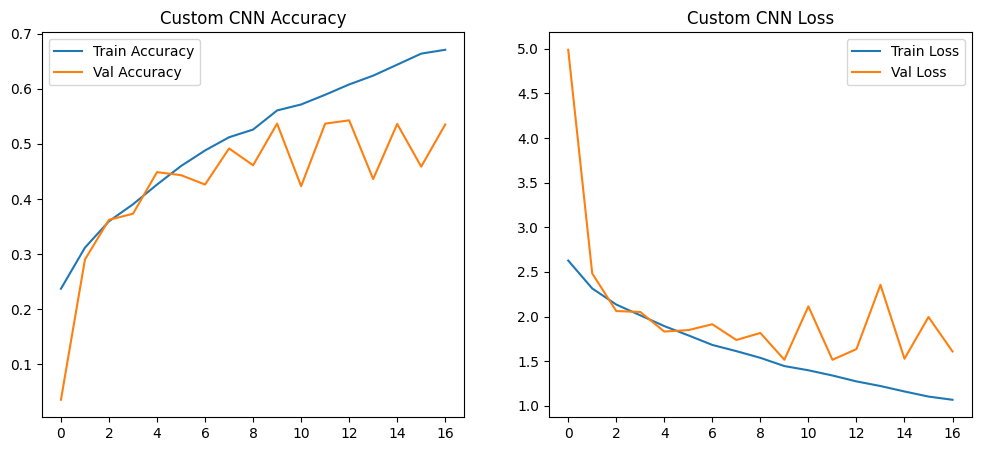

In [13]:
def plot_custom_results(history, filename="custom_cnn_learning_curves.png"):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Custom CNN Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Custom CNN Loss')
    plt.legend()
    
    os.makedirs('../results/figures', exist_ok=True)
    plt.savefig(f'../results/figures/{filename}', dpi=300)
    plt.show()

plot_custom_results(history)